In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("77.house_price_dataset.csv")

df

,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished,price
0,3419,1,1,3,1,8,4.5,4,0,119.0
1,930,1,1,2,1,17,12.8,8,0,61.3
2,3032,4,4,4,2,1,15.7,5,1,131.1
3,1436,2,2,1,0,13,3.7,10,1,97.3
4,977,4,3,4,0,18,7.3,9,1,89.5
...,...,...,...,...,...,...,...,...,...,...
95,1885,3,4,1,2,22,17.5,7,1,93.0
96,2798,5,4,1,1,21,14.3,6,0,116.9
97,2577,1,1,4,1,23,7.4,4,0,83.9
98,1029,3,3,3,3,5,6.4,7,0,80.8


In [8]:
# check missing values
df.isnull().sum()

area              0
bedrooms          0
bathrooms         0
stories           0
parking           0
age               0
distance_city     0
location_score    0
furnished         0
price             0
dtype: int64

In [9]:
X = df.drop("price", axis=1)
y = df["price"]

X

,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished
0,3419,1,1,3,1,8,4.5,4,0
1,930,1,1,2,1,17,12.8,8,0
2,3032,4,4,4,2,1,15.7,5,1
3,1436,2,2,1,0,13,3.7,10,1
4,977,4,3,4,0,18,7.3,9,1
...,...,...,...,...,...,...,...,...,...
95,1885,3,4,1,2,22,17.5,7,1
96,2798,5,4,1,1,21,14.3,6,0
97,2577,1,1,4,1,23,7.4,4,0
98,1029,3,3,3,3,5,6.4,7,0


In [10]:
y

0     119.0
1      61.3
2     131.1
3      97.3
4      89.5
      ...  
95     93.0
96    116.9
97     83.9
98     80.8
99     96.3
Name: price, Length: 100, dtype: float64

In [11]:
X = pd.get_dummies(X, columns=["furnished"], drop_first=True)
X


,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished_1
0,3419,1,1,3,1,8,4.5,4,False
1,930,1,1,2,1,17,12.8,8,False
2,3032,4,4,4,2,1,15.7,5,True
3,1436,2,2,1,0,13,3.7,10,True
4,977,4,3,4,0,18,7.3,9,True
...,...,...,...,...,...,...,...,...,...
95,1885,3,4,1,2,22,17.5,7,True
96,2798,5,4,1,1,21,14.3,6,False
97,2577,1,1,4,1,23,7.4,4,False
98,1029,3,3,3,3,5,6.4,7,False


In [12]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Fill missing values using Mean/Median
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

In [14]:
X_train.isnull().sum()
X_test.isnull().sum()

area              0
bedrooms          0
bathrooms         0
stories           0
parking           0
age               0
distance_city     0
location_score    0
furnished_1       0
dtype: int64

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.03, 2.54, 3.45,...,-0.73, 4.33, 5.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['area','bedrooms','bathrooms',...,'distance_city','location_score', 'furnished_1']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.658
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [17]:
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "Actual Price": y_test.values,
    "Prediction Price": y_pred
})

compare

,Actual Price,Prediction Price
0,102.1,99.986792
1,150.1,152.602085
2,101.2,96.080361
3,114.2,123.698068
4,109.5,110.754929
5,80.2,79.584990
6,84.9,94.798702
7,131.5,134.615157
8,122.2,114.545313
9,119.0,116.569371


In [18]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [ 0.02590717  2.53728455  3.4501386   1.44302804  1.50334475 -0.44009759
 -0.729006    4.32901179  5.76287976]
Intercept: 5.6581590625189335


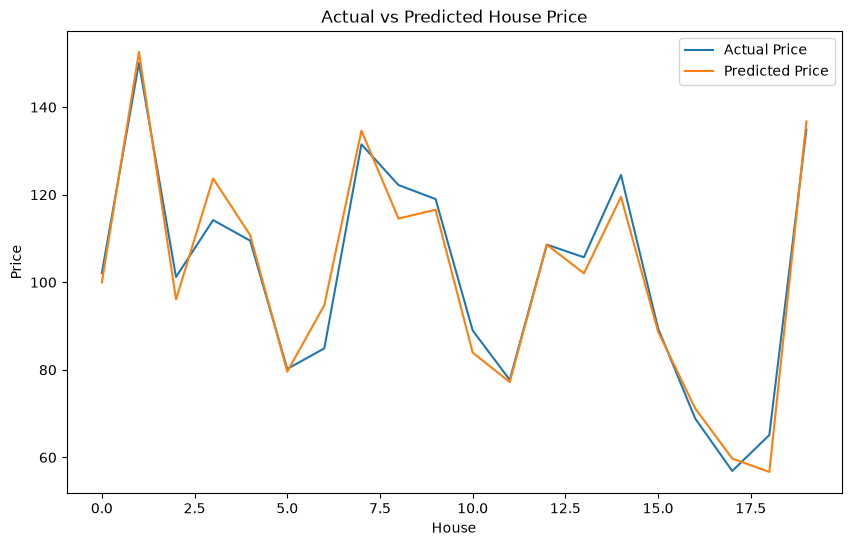

In [19]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.xlabel("House")
plt.ylabel("Price")
plt.title("Actual vs Predicted House Price")

plt.legend()
plt.show()

In [28]:
new_house = pd.DataFrame({
    "bathrooms": [2],
    "stories": [2],
    "parking": [1],
    "age": [5],
    "distance_city": [10],
    "location_score": [8],
    "furnished": ["Yes"]
})

In [29]:
new_house = pd.get_dummies(
    new_house,
    columns=["furnished"],
    drop_first=True
)

In [30]:
new_house = new_house.reindex(columns=X.columns, fill_value=0)
new_price = model.predict(new_house)

print("Predicted House Price:", new_price[0])

Predicted House Price: 42.08938345416502


In [31]:
print("Model Score:", model.score(X_test, y_test))


Model Score: 0.9618772023152126


In [32]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 3.730920380080481


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 22.69496941909552


In [34]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 4.763923741947967
